In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model

import joblib

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.shape

(768, 9)

In [7]:
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for column in columns_with_zero:
    df[column] = df[column].replace(0, df[column].median())

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


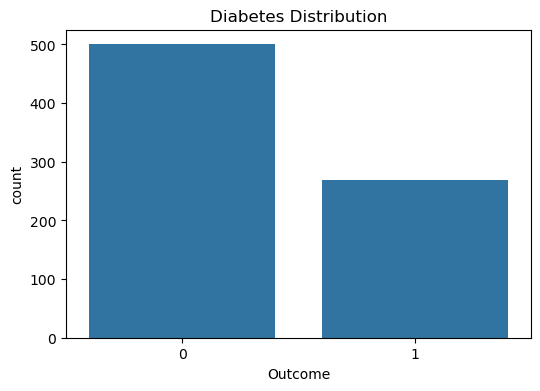

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Distribution')
plt.show()

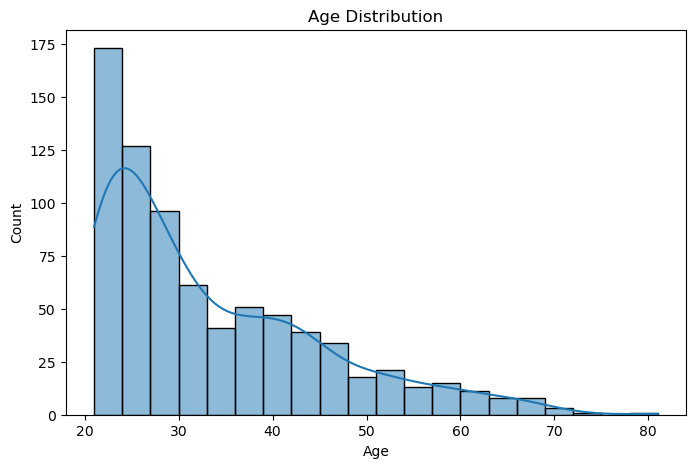

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

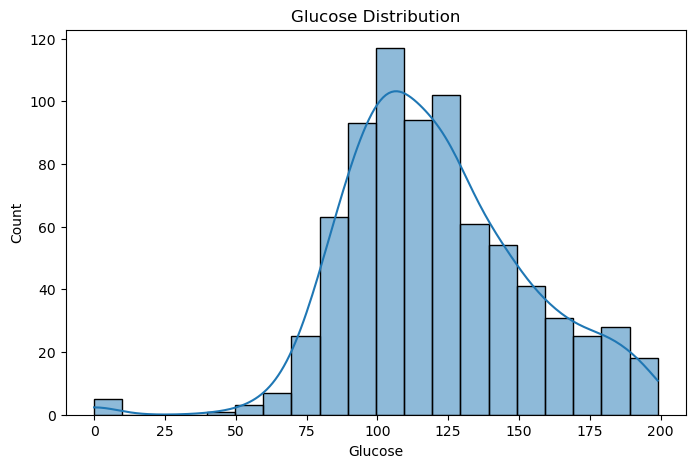

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Glucose'], bins=20, kde=True)
plt.title('Glucose Distribution')
plt.show()

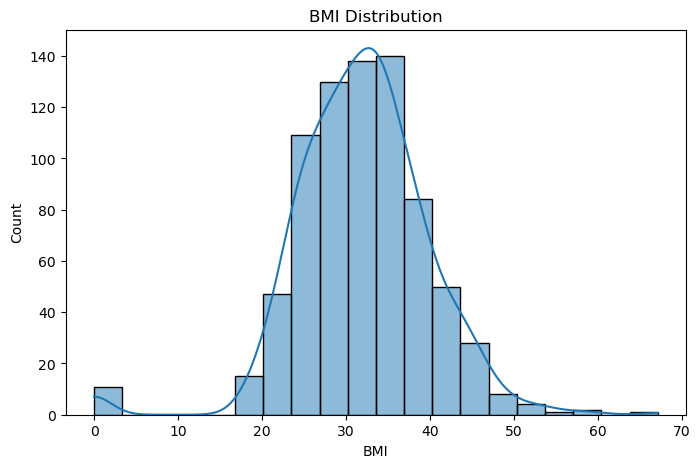

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.show()

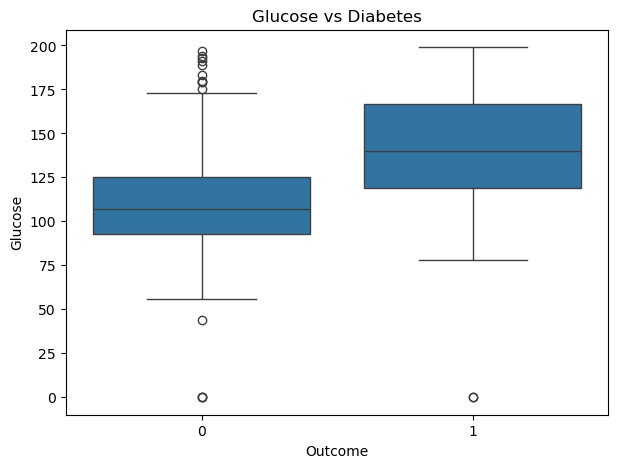

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose vs Diabetes')
plt.show()

In [9]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
joblib.dump(scaler, 'scaler.pkl')

print("Scaler saved successfully.")

Scaler saved successfully.


In [14]:
model = Sequential()

In [15]:
model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.add(Dense(8, activation='relu'))

In [17]:
model.add(Dense(1, activation='sigmoid'))

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5234 - loss: 0.6911 - val_accuracy: 0.6016 - val_loss: 0.6583
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6354 - loss: 0.6306 - val_accuracy: 0.6341 - val_loss: 0.6205
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6558 - loss: 0.5898 - val_accuracy: 0.6260 - val_loss: 0.5957
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6762 - loss: 0.5603 - val_accuracy: 0.6423 - val_loss: 0.5760
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6904 - loss: 0.5387 - val_accuracy: 0.6423 - val_loss: 0.5638
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6945 - loss: 0.5244 - val_accuracy: 0.6504 - val_loss: 0.5519
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7088 - loss: 0.5112 - val_accuracy: 0.6667 - val_loss: 0.5410
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7352 - loss: 0.5006 - val_accuracy: 0.6911 - val_los

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7532 - loss: 0.5445
Test Accuracy: 0.7532467246055603


In [22]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



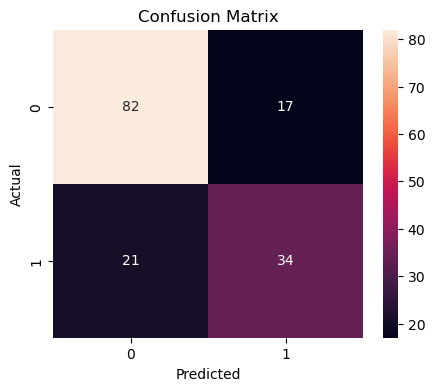

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
model.save('diabetes_ann_model.h5')

print("Model saved successfully.")

Model saved successfully.


In [25]:
loaded_model = load_model('diabetes_ann_model.h5')

print("Model loaded successfully.")

Model loaded successfully.


In [26]:
sample_data = np.array([[5,120,70,20,79,25.0,0.5,33]])

In [27]:
sample_data = scaler.transform(sample_data)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [28]:
prediction = loaded_model.predict(sample_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


In [29]:
print(prediction)

if prediction[0][0] > 0.5:
    print("Diabetic")
else:
    print("Non-Diabetic")

[[0.11163079]]
Non-Diabetic
